# Build one local datacube for a small ROI

Create a small local cube using the 4DMED-SEA sea-surface salinity source dataset (`sos`), available as Zarr on its native grid. The [dataset notebook](../1_Datasets/4dmed-ss/access.ipynb) describes this input.

The example selects one day in a 2° by 2° Alboran Sea region, resamples it to a 1/12° grid, saves it as Zarr, and plots the result.

The [overview](0_intro.ipynb) describes the original cube workflows.

In [6]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
from pyproj import CRS

AOI_CENTER_LON_LAT = (-2.5, 36.0)
AOI_WIDTH_DEG = 2.0
TARGET_RESOLUTION_DEG = 1 / 12
TIME_TARGET = "2019-06-01"

# Work from either the repository root or the notebook directory.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "myst.yml").exists() else Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / "downloaded_data"
FINAL_CUBE = OUTPUT_DIR / "alboran_daily_demo_cube.zarr"

## 1. Open the Source Dataset

Open the 4DMED-SEA salinity dataset. The data remain lazy until the selected region is written below.

In [7]:
INPUT_PATH = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/sssd.zarr"
source_dataset = xr.open_zarr(
    INPUT_PATH, chunks={}, decode_coords="all",
)

## 2. Select and Resample a Small Region

Create the new grid, select surface salinity (`depth=0`) for one day, and copy the nearest source value to each target cell. A small buffer around the region supplies neighbouring cells for interpolation. Missing values remain missing.

The default settings produce a 24 × 24 grid. The date slice includes the source observation for that day, normally timestamped at noon, and keeps its time dimension.

In [8]:
half_width = AOI_WIDTH_DEG / 2
left, right = AOI_CENTER_LON_LAT[0] - half_width, AOI_CENTER_LON_LAT[0] + half_width
bottom, top = AOI_CENTER_LON_LAT[1] - half_width, AOI_CENTER_LON_LAT[1] + half_width

n_cells = int(round(AOI_WIDTH_DEG / TARGET_RESOLUTION_DEG))
offsets = (np.arange(n_cells) + 0.5) * TARGET_RESOLUTION_DEG
target_lon = left + offsets
target_lat = bottom + offsets

source = source_dataset[["sos"]].sel(
    time=slice(TIME_TARGET, TIME_TARGET), depth=0, drop=True,
    lon=slice(left - 0.25, right + 0.25),
    lat=slice(bottom - 0.25, top + 0.25),
)
cube = source.interp(lon=target_lon, lat=target_lat, method="nearest")
cube

<xarray.Dataset> Size: 5kB
Dimensions:  (time: 1, lat: 24, lon: 24)
Coordinates:
  * time     (time) datetime64[ns] 8B 2019-06-01T12:00:00
  * lat      (lat) float64 192B 35.04 35.12 35.21 35.29 ... 36.79 36.88 36.96
  * lon      (lon) float64 192B -3.458 -3.375 -3.292 ... -1.708 -1.625 -1.542
Data variables:
    sos      (time, lat, lon) float64 5kB dask.array<chunksize=(1, 24, 24), meta=np.ndarray>
Attributes: (12/16)
    Conventions:            CF-1.7
    title:                  Mediterranean Analysed Sea Surface Salinity and D...
    institution:            CNR
    netcdf_version_id:      4.9.3-development of Jun  4 2023 14:13:36 
    creation_date:          Mon 11 Sep 2023 09:30:47
    product_version:        1.0
    ...                     ...
    northernmost_latitude:  45.979168
    Scaling_Equation:       (scale_factor*data) + add_offset
    grid_resolution:        0.0416 degrees
    references:             Buongiorno Nardelli, B., R. Droghei, and R. Santo...
    history:                Fri Feb  9 09:26:09 2024: ncatted -O -a reference...
    NCO:                    netCDF Operators version 4.8.1 (Homepage = http:/...

## 3. Save the Local Cube

Record the coordinate system, grid spacing, and source, then write the selected data to `downloaded_data/alboran_daily_demo_cube.zarr`.

`mode="w-"` keeps an existing result from being overwritten. Choose a new output filename to run the write again.

In [9]:
crs_wkt = CRS.from_epsg(4326).to_wkt()
cube["spatial_ref"] = xr.DataArray(0, attrs={"crs_wkt": crs_wkt, "spatial_ref": crs_wkt})
cube.sos.attrs["grid_mapping"] = "spatial_ref"
cube.attrs = {
    "title": "Alboran Sea salinity demonstration cube",
    "crs": "EPSG:4326",
    "target_resolution_degrees": TARGET_RESOLUTION_DEG,
    "source_store": INPUT_PATH,
    "interpolation_method": "nearest",
}

# Clear the source storage settings before writing the new grid.
for name in cube.variables:
    cube[name].encoding = {}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with ProgressBar():
    cube.chunk({"time": 1, "lat": -1, "lon": -1}).to_zarr(
        FINAL_CUBE, mode="w-", consolidated=True, zarr_format=2,
    )

[########################################] | 100% Completed | 1.71 sms


## 4. Open and Plot the Result

Read the local cube and plot sea-surface salinity for the selected day.

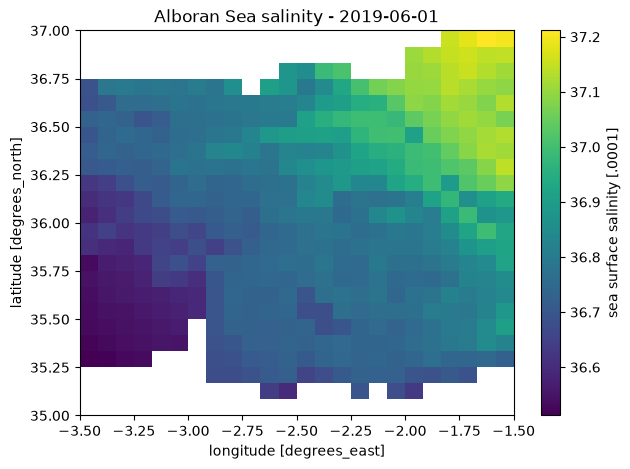

In [10]:
demo_cube = xr.open_zarr(FINAL_CUBE, consolidated=True, decode_coords="all")
demo_cube.sos.isel(time=0).plot(figsize=(7, 5), cmap="viridis")
plt.title(f"Alboran Sea salinity - {TIME_TARGET}")
plt.show()

demo_cube.close()
source_dataset.close()